[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mihirathavale/Guided_growth_BO_tutorial/blob/main/bayesian_optimization_device_growth.ipynb)

<div style="background:linear-gradient(135deg,#1E3A6E 70%,#2E5BAA);
            padding:48px 52px 44px;border-radius:14px;color:white;
            font-family:'Georgia',serif;">
  <div style="font-size:13px;letter-spacing:4px;color:#CFE0FA;
              font-family:'Trebuchet MS',sans-serif;margin-bottom:14px;">
    HANDS-ON TUTORIAL
  </div>
  <div style="font-size:40px;font-weight:bold;line-height:1.18;margin-bottom:18px;">
    Bayesian Optimization for<br>Microring Laser Growth
  </div>
  <div style="font-size:17px;color:#CFE0FA;font-family:'Trebuchet MS',sans-serif;
              line-height:1.6;margin-bottom:28px;">
    A self-contained, runnable notebook — no machine-learning background needed.<br>
    We go from a toy growth problem → DoE warm-start → single-objective BO →
    multi-objective BO → the real OMS-lab pipeline → BoTorch under the hood.
  </div>
  <div style="background:rgba(255,255,255,0.12);border-radius:9px;
              padding:14px 20px;font-family:'Trebuchet MS',sans-serif;font-size:14px;">
    <b style="color:#E8643C;">How to use this notebook</b><br>
    1 · Run the <b>Setup</b> cell (Section 0), then <b>Runtime → Restart session</b> once.<br>
    2 · <b>Runtime → Run all</b> — every cell runs in &lt;2 min on a free Colab CPU.<br>
    3 · Play with the <b>sliders</b> (🔬 and ⚙️ cells) — drag, re-run, see what changes.<br>
    4 · The <b>💬 "Try it" prompts</b> throughout suggest things to experiment with.
  </div>
  <div style="margin-top:22px;font-family:'Trebuchet MS',sans-serif;font-size:13.5px;color:#CFE0FA;">
    Companion repo &nbsp;→&nbsp;
    <a href="https://github.com/OMS-lab/Microring_MOBO"
       style="color:#E8643C;">github.com/OMS-lab/Microring_MOBO</a>
    &nbsp;·&nbsp; Generate your own BO template at
    <a href="https://honegumi.readthedocs.io" style="color:#E8643C;">honegumi.readthedocs.io</a>
  </div>
</div>

---
## 📦 Section 0 · Setup

<div style="background:#FFF3CD;border-left:5px solid #E8643C;
            padding:14px 18px;border-radius:6px;font-family:'Trebuchet MS',sans-serif;">
<b>Run this cell first, then do Runtime → Restart session once before continuing.</b><br>
The two version pins below are not optional — without them Ax crashes silently
(pandas 3.0 and numpy 2.x both break internal Ax transforms).
</div>

In [ ]:
# ── install everything we need ──────────────────────────────────────────────
# ax-platform  : the Bayesian optimization framework (wraps BoTorch)
# botorch      : GP models and acquisition functions
# numpy<2      : numpy 2.x breaks torch/BoTorch internals
# pandas<2.3   : pandas 3.0 CoW makes Ax's winsorization crash
!pip install -q "ax-platform==0.5.0" "botorch==0.13.0" "numpy<2" "pandas<2.3"
print("✅ Done. Now: Runtime → Restart session, then Runtime → Run all.")

---
## 🧭 Section 1 · What is Bayesian Optimization? *(read this first)*

<div style="background:#EEF3FB;border-radius:10px;padding:22px 26px 18px;
            font-family:'Trebuchet MS',sans-serif;line-height:1.7;">

### The problem
You want the best microring laser recipe. You have three knobs to turn
(growth temperature, V/III ratio, ring radius) and can only afford a
**handful of expensive growth runs** — maybe 20–30. You cannot grid-search
the whole space.

### Why random search fails
Random picks might cluster together and miss entire promising regions.
You'd need hundreds of runs to stumble onto the optimum by chance.

### What BO does instead
Bayesian optimization keeps a **mental model** of the "recipe → performance" map
and uses it to pick the **most informative next recipe** every time:

<table style="width:100%;border-collapse:collapse;margin-top:10px;">
<tr style="background:#1E3A6E;color:white;font-weight:bold;">
  <td style="padding:9px 14px;border-radius:6px 0 0 0;">Step</td>
  <td style="padding:9px 14px;">What happens</td>
  <td style="padding:9px 14px;border-radius:0 6px 0 0;">In plain words</td>
</tr>
<tr style="background:#f4f7fd;">
  <td style="padding:9px 14px;font-weight:bold;color:#1E3A6E;">① Propose</td>
  <td style="padding:9px 14px;">Acquisition function scores all untried recipes</td>
  <td style="padding:9px 14px;color:#475067;">"Which recipe would teach us the most?"</td>
</tr>
<tr>
  <td style="padding:9px 14px;font-weight:bold;color:#E8643C;">② Run</td>
  <td style="padding:9px 14px;">Grow the device, measure the result</td>
  <td style="padding:9px 14px;color:#475067;">One real (or simulated) experiment</td>
</tr>
<tr style="background:#f4f7fd;">
  <td style="padding:9px 14px;font-weight:bold;color:#1E3A6E;">③ Update</td>
  <td style="padding:9px 14px;">Gaussian process surrogate is refitted</td>
  <td style="padding:9px 14px;color:#475067;">"Now I know a little more about the landscape"</td>
</tr>
<tr>
  <td style="padding:9px 14px;font-weight:bold;color:#475067;">④ Repeat</td>
  <td style="padding:9px 14px;">Until the budget is spent</td>
  <td style="padding:9px 14px;color:#475067;">Each run is smarter than the last</td>
</tr>
</table>

### Two key terms
- **Explore vs exploit** — the model knows *where it's unsure*. It balances
  testing recipes it *thinks* are good (exploit) against testing recipes it
  knows little about (explore). This is why it beats random in so few runs.
- **Pareto front** *(multi-objective only)* — when two goals conflict, there
  is no single "best". The Pareto front is the set of recipes where you
  cannot improve one goal without hurting the other.
</div>

---
## 🔬 Section 2 · The toy growth problem

Instead of a real MOVPE system, we use a **simulator** that takes three
knobs and returns two device metrics. This keeps every cell fast and free,
but the BO logic is identical to the real pipeline.

| Knob | What it represents | Range |
|---|---|---|
| `growth_temp` | MOVPE growth temperature | 480 – 560 °C |
| `v_iii_ratio` | Group-V / group-III precursor flow | 5 – 50 |
| `ring_radius` | Microring radius (geometry) | 2 – 10 µm |

| Output | We want it… | Why it matters |
|---|---|---|
| **PL intensity** (a.u.) | **HIGH** | Brightness of the device |
| **Emission wavelength** (nm) | **Close to a target** | O-band telecom ≈ 1310 nm |

> **The trade-off that makes this interesting:**
> The brightest recipe emits near ~1348 nm.
> Hitting 1310 nm requires a *different* recipe.
> You can't win both at once — which is exactly why we need multi-objective BO.

We also add a little random noise to mimic the **device-to-device variation**
seen between nominally identical growths.

In [ ]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── The simulator ───────────────────────────────────────────────────────────
# In a real project you REPLACE this function with your actual measurement.
# Everything else in the notebook stays the same.
def device_response(temp, v_iii, radius, noise=True, rng=np.random):
    # Rescale each knob to ~[0,1] so the equations below are readable
    t = (temp   - 480) / 80.0
    v = (v_iii  -   5) / 45.0
    r = (radius -   2) /  8.0

    # PL intensity: smooth hill peaking at high-T, mid V/III, mid radius
    pl = 100 * np.exp(
        -((t - 0.7)**2) / 0.08
        -((v - 0.5)**2) / 0.15
        -((r - 0.55)**2) / 0.25
    )

    # Emission wavelength: rises with T, falls with V/III, rises with radius
    # The PL-optimal recipe lands near 1348 nm → hitting 1310 nm costs brightness
    wl = 1290 + 90*t - 30*v + 25*r

    if noise:
        pl += rng.normal(0, 3.0)   # device-to-device scatter
        wl += rng.normal(0, 2.0)
    return float(max(pl, 0.0)), float(wl)

# ── Visualise the landscape ─────────────────────────────────────────────────
T = np.linspace(480, 560, 120)
V = np.linspace(5,  50,  120)
TT, VV = np.meshgrid(T, V)

PL = np.array([[device_response(tt, vv, 6.0, noise=False)[0] for tt in T] for vv in V])
WL = np.array([[device_response(tt, vv, 6.0, noise=False)[1] for tt in T] for vv in V])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))

c1 = ax1.contourf(TT, VV, PL, levels=20, cmap="viridis")
ax1.contour(TT, VV, PL, levels=8, colors="white", linewidths=0.4, alpha=0.5)
ax1.set_xlabel("growth temperature (°C)"); ax1.set_ylabel("V/III ratio")
ax1.set_title("PL intensity landscape (radius = 6 µm)")
plt.colorbar(c1, ax=ax1, label="PL (a.u.)")

c2 = ax2.contourf(TT, VV, WL, levels=20, cmap="RdYlBu_r")
ax2.contour(TT, VV, WL, levels=8, colors="white", linewidths=0.4, alpha=0.5)
ax2.set_xlabel("growth temperature (°C)"); ax2.set_ylabel("V/III ratio")
ax2.set_title("Emission wavelength landscape (radius = 6 µm)")
plt.colorbar(c2, ax=ax2, label="wavelength (nm)")

plt.suptitle("BO never sees these maps — it learns them from the runs it chooses",
             fontsize=11, style="italic", color="#475067", y=1.01)
plt.tight_layout(); plt.show()

print("PL optimum is at high-T / mid V/III and emits near",
      round(device_response(540, 27, 6, noise=False)[1]), "nm")
print("1310 nm target needs lower-T / higher V/III → brightness drops")

### 🔬 Try a growth recipe by hand

Use the sliders below, re-run the cell, and try to get
**both** high PL **and** an emission near 1310 nm.
It is surprisingly hard — that tension is exactly what BO is for.

In [ ]:
#@markdown #### Drag the knobs, then press ▶ to see what device you get
growth_temp = 530   #@param {type:"slider", min:480, max:560, step:2}
v_iii_ratio = 28    #@param {type:"slider", min:5,   max:50,  step:1}
ring_radius  = 6.0  #@param {type:"slider", min:2.0, max:10.0,step:0.5}

pl, wl = device_response(growth_temp, v_iii_ratio, ring_radius, noise=False)
wl_target = 1310

score_pl  = min(100, round(pl))
score_wl  = max(0, round(100 - 2*abs(wl - wl_target)))  # penalty for being off-target

print(f"━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print(f"  Recipe:  T = {growth_temp} °C   V/III = {v_iii_ratio}   r = {ring_radius} µm")
print(f"━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print(f"  PL intensity      = {pl:5.1f} a.u.   {'🟢 bright!' if pl > 70 else '🟡 ok' if pl > 40 else '🔴 dim'}")
print(f"  Emission λ        = {wl:5.0f} nm    target = {wl_target} nm  |Δλ| = {abs(wl-wl_target):.0f} nm")
print(f"━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
print(f"  PL score          = {score_pl}/100")
print(f"  Wavelength score  = {score_wl}/100  (100 = exactly on target)")
print(f"  Combined score    = {(score_pl+score_wl)//2}/100  ← try to beat 70!")

---
## 📐 Section 3 · Design of Experiments — a smart first batch

Before BO can be clever, it needs *some* data to start from.
**Where should those first runs go?**

<div style="display:flex;gap:16px;margin-top:6px;font-family:'Trebuchet MS',sans-serif;">
  <div style="flex:1;background:#fdecea;border-radius:8px;padding:14px 16px;">
    <b style="color:#c0392b;">❌ Random sampling</b><br>
    Quick, but points can clump together and leave entire regions unexplored.
  </div>
  <div style="flex:1;background:#fef9e7;border-radius:8px;padding:14px 16px;">
    <b style="color:#b7770d;">⚠️ Full-factorial grid</b><br>
    Even, but explodes: 5 levels × 3 knobs = <b>125 runs</b>.
    We can only afford ~8.
  </div>
  <div style="flex:1;background:#eafaf1;border-radius:8px;padding:14px 16px;">
    <b style="color:#1E3A6E;">✅ Latin Hypercube (LHS)</b><br>
    Divides each knob range into equal slices and places exactly one point
    per slice — maximum coverage in minimum runs.
    <b>This is what the OMS-lab repo uses.</b>
  </div>
</div>

A good DoE batch gives the surrogate model an even picture of the whole
space so BO starts **informed instead of blind**.

In [ ]:
#@markdown #### ⚙️ DoE settings
n_doe   = 8   #@param {type:"slider", min:4, max:20, step:1}
doe_seed = 0  #@param {type:"integer"}
print(f"Generating a Latin-Hypercube design of {n_doe} runs (seed {doe_seed})…")

In [ ]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import qmc

# ── 1. Build the LHS design ──────────────────────────────────────────────────
lows  = np.array([480.0,  5.0, 2.0])
highs = np.array([560.0, 50.0, 10.0])
names = ["growth_temp", "v_iii_ratio", "ring_radius"]

unit_pts = qmc.LatinHypercube(d=3, seed=doe_seed).random(n=n_doe)
design   = qmc.scale(unit_pts, lows, highs)      # shape (n_doe, 3)

# ── 2. Run each recipe through the simulator ─────────────────────────────────
rng_doe = np.random.RandomState(doe_seed)
rows = []
for x in design:
    pl, wl = device_response(*x, rng=rng_doe)
    rows.append([*x, pl, wl])
doe_df = pd.DataFrame(rows, columns=names + ["pl_intensity", "wavelength"])

print("Your DoE starting dataset (measured before any BO):")
display(doe_df.round(1))

# ── 3. Compare LHS vs random vs grid (2-D slice: T vs V/III) ─────────────────
rand_unit = np.random.RandomState(doe_seed).random((n_doe, 3))
rand2 = qmc.scale(rand_unit[:, :2], lows[:2], highs[:2])
grid2 = np.array(
    np.meshgrid(np.linspace(lows[0], highs[0], 3),
                np.linspace(lows[1], highs[1], 3))
).reshape(2, -1).T
lhs2 = qmc.scale(qmc.LatinHypercube(d=2, seed=doe_seed).random(n_doe), lows[:2], highs[:2])

panels = [
    (rand2, "#d9534f", "Random (%d pts)" % n_doe,              "clumps & gaps"),
    (grid2, "#888888", "Full-factorial grid",                   "(9 pts for 3 levels)"),
    (lhs2,  "#1f4e9c", "Latin Hypercube (%d pts)" % n_doe,     "even coverage  ✓"),
]
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharey=True)
for ax, (pts, col, t1, t2) in zip(axes, panels):
    ax.scatter(pts[:, 0], pts[:, 1], color=col, s=80, edgecolor="white", zorder=3)
    ax.set_xlabel("growth temperature (°C)", fontsize=10)
    ax.set_facecolor("#f8f9fc")
    ax.grid(color="white", lw=1.5, zorder=0)
    is_lhs = (col == "#1f4e9c")
    ax.set_title(t1 + "\n" + t2, fontsize=10.5,
                 color="#1E3A6E" if is_lhs else "#475067",
                 fontweight="bold" if is_lhs else "normal")
axes[0].set_ylabel("V/III ratio", fontsize=10)

disc_lhs = qmc.discrepancy(unit_pts)
disc_rnd = qmc.discrepancy(rand_unit)
plt.suptitle(
    "Coverage score (lower = better):  LHS %.3f   vs   Random %.3f" % (disc_lhs, disc_rnd),
    fontsize=11, y=1.02, style="italic", color="#475067")
plt.tight_layout()
plt.show()


### ▶️ DoE → BO warm start

The DoE runs above become the optimizer's **starting data**.
BO is then attached to those results and immediately proposes the *next* recipe,
already informed by what we've seen — rather than wasting the first few
guesses on random Sobol points.

This is exactly the DoE → BO handoff the OMS-lab `Microring_MOBO` pipeline uses.

In [ ]:
#@markdown #### Extra BO runs after the DoE batch:
n_bo_after_doe = 12  #@param {type:"slider", min:4, max:30, step:1}

import warnings; warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
from ax.service.ax_client import AxClient, ObjectiveProperties

rng_ws = np.random.RandomState(doe_seed)
ax_ws  = AxClient(verbose_logging=False, random_seed=doe_seed)
ax_ws.create_experiment(
    name="doe_warmstart",
    parameters=[
        {"name": "growth_temp", "type": "range", "bounds": [480.0, 560.0]},
        {"name": "v_iii_ratio", "type": "range", "bounds": [5.0,  50.0]},
        {"name": "ring_radius", "type": "range", "bounds": [2.0,  10.0]},
    ],
    objectives={"pl_intensity": ObjectiveProperties(minimize=False)},
)

# Warm start: attach the DoE recipes we already ran
for row in design:
    temp, v_iii, radius = float(row[0]), float(row[1]), float(row[2])
    p = {"growth_temp": temp, "v_iii_ratio": v_iii, "ring_radius": radius}
    _, idx = ax_ws.attach_trial(parameters=p)
    pl, _  = device_response(temp, v_iii, radius, rng=rng_ws)
    ax_ws.complete_trial(trial_index=idx, raw_data={"pl_intensity": (pl, None)})

# BO takes over
for _ in range(n_bo_after_doe):
    p, idx = ax_ws.get_next_trial()
    pl, _  = device_response(
        p["growth_temp"], p["v_iii_ratio"], p["ring_radius"], rng=rng_ws)
    ax_ws.complete_trial(trial_index=idx, raw_data={"pl_intensity": (pl, None)})

# Plot the DoE -> BO handoff
df_ws   = ax_ws.get_trials_data_frame().sort_values("trial_index")
best_ws = df_ws["pl_intensity"].cummax().values

fig, ax = plt.subplots(figsize=(8, 4))
ax.fill_betweenx([0, 105], [0.5], [n_doe + 0.5],
                 color="#ffe7df", alpha=0.85, label="DoE batch (LHS)")
ax.fill_betweenx([0, 105], [n_doe + 0.5], [len(best_ws) + 0.5],
                 color="#e8f0fc", alpha=0.75, label="BO phase")
ax.plot(range(1, len(best_ws)+1), best_ws, "-o", color="#2E5BAA", lw=2.4, ms=5)
ax.axvline(n_doe + 0.5, color="#E8643C", lw=1.8, ls="--")
ax.annotate("BO takes over", (n_doe + 0.7, 22),
            fontsize=10, color="#E8643C", fontweight="bold")
ax.set_xlim(0.3, len(best_ws) + 0.7)
ax.set_ylim(0, 105)
ax.set_xlabel("run number")
ax.set_ylabel("best PL intensity so far")
ax.set_title("DoE gives a warm start; BO refines from there")
ax.legend(fontsize=9, loc="lower right")
plt.tight_layout()
plt.show()

bp, (m, _) = ax_ws.get_best_parameters()
print("Best after DoE + BO:")
print("  T=%.0f C   V/III=%.0f   r=%.1f um" % (
    bp["growth_temp"], bp["v_iii_ratio"], bp["ring_radius"]))
print("  Predicted PL = %.1f a.u." % m["pl_intensity"])


> 💬 **Try it:** reduce `n_doe` to 4 — does BO still find a good recipe?
> Increase `n_bo_after_doe` — at what point does the curve flatten?

---
## 🧩 Section 4 · Honegumi — getting a BO script in one click

[**Honegumi**](https://honegumi.readthedocs.io) ("skeletal framework") is an
interactive template generator for BO built on the Ax platform.
You open the website, toggle options in a grid, and it hands you a
unit-tested script. **You only change the parameters, objectives, and
the function that runs your experiment.**

The grid below shows every toggle, our choice for the toy problem, and the
reason — this is the same grid you'd fill in on the Honegumi website.

<div style="text-align:center;margin:18px 0 6px;">
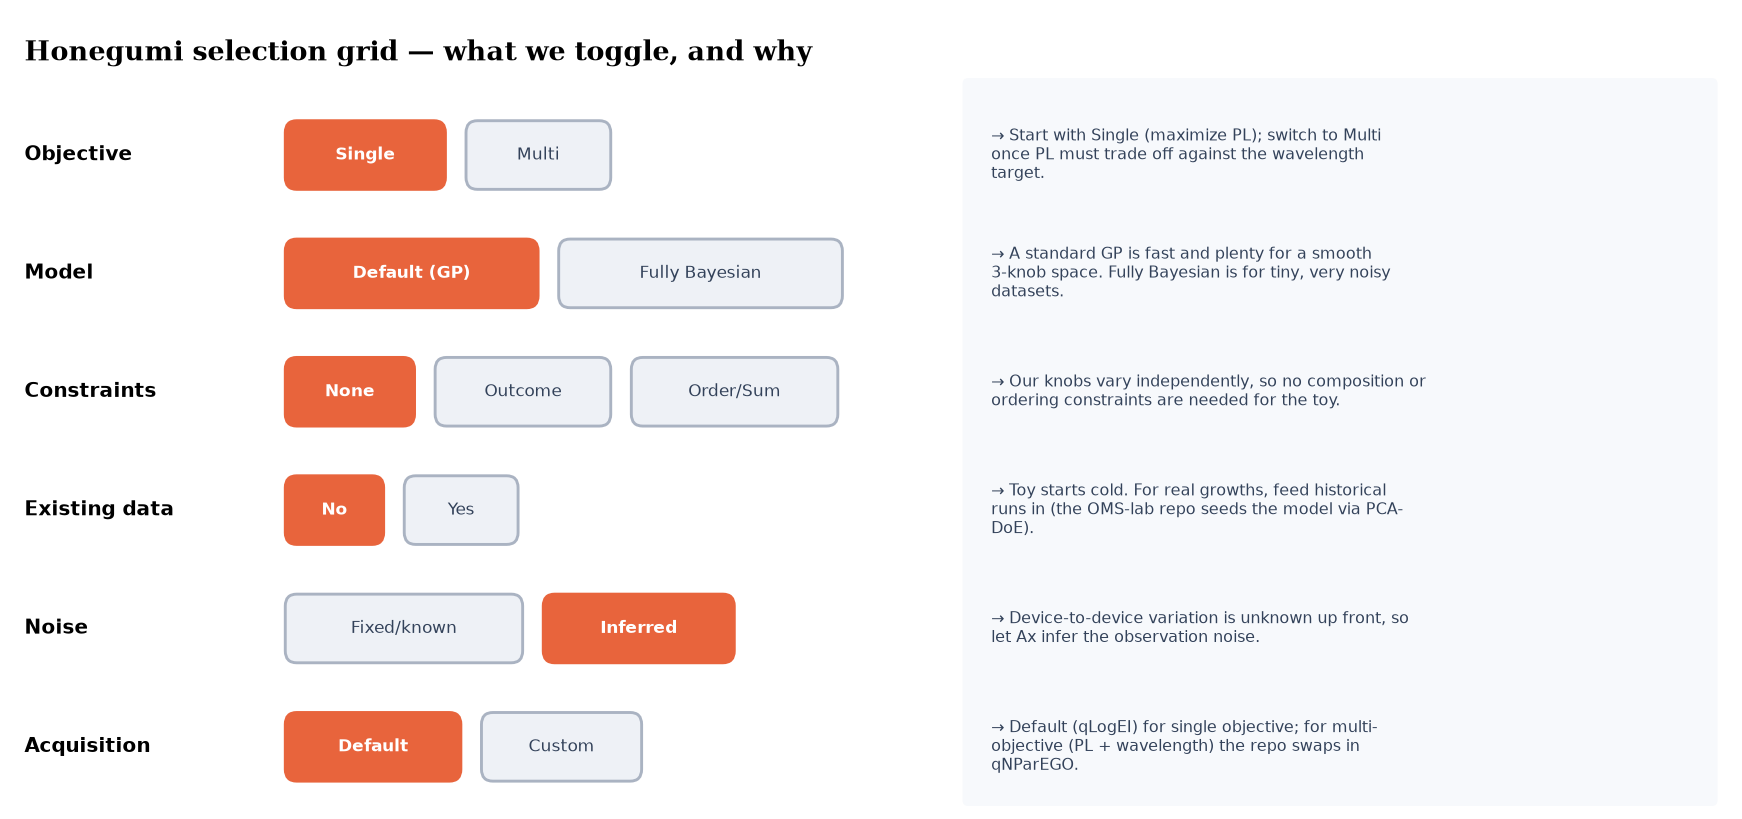
</div>

The key toggle is **Objective: Single vs Multi** — we'll do both.

---
## 🎯 Section 5 · Single-objective BO — get the brightest device

**Goal:** maximize PL intensity, ignoring wavelength for now.

The code below is essentially what Honegumi generates for a single-objective
problem. The BO loop is three lines:

```python
params = ax_client.get_next_trial()      # model proposes the next recipe
result = run_experiment(params)          # your measurement (here: simulator)
ax_client.complete_trial(result)         # feed the result back
```

The first few trials are **quasi-random (Sobol)** to seed the model.
After that, a Gaussian-process surrogate picks recipes that balance
**exploiting** known-good regions and **exploring** uncertain ones.

In [ ]:
#@markdown #### ⚙️ Single-objective settings
n_trials    = 18  #@param {type:"slider", min:8, max:40, step:1}
random_seed =  0  #@param {type:"integer"}
print(f"{n_trials} trials · seed {random_seed}")

In [ ]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
from ax.service.ax_client import AxClient, ObjectiveProperties

rng_so = np.random.RandomState(random_seed)

# ── 1. Create the experiment ─────────────────────────────────────────────────
ax_so = AxClient(verbose_logging=False, random_seed=random_seed)
ax_so.create_experiment(
    name="microring_PL_single",
    parameters=[
        {"name": "growth_temp", "type": "range", "bounds": [480.0, 560.0]},
        {"name": "v_iii_ratio", "type": "range", "bounds": [5.0,  50.0]},
        {"name": "ring_radius", "type": "range", "bounds": [2.0,  10.0]},
    ],
    objectives={"pl_intensity": ObjectiveProperties(minimize=False)},  # maximize PL
)

# ── 2. The BO loop ────────────────────────────────────────────────────────────
def eval_so(p):
    pl, _ = device_response(
        p["growth_temp"], p["v_iii_ratio"], p["ring_radius"], rng=rng_so)
    return {"pl_intensity": (pl, None)}   # (value, noise=None → infer from data)

for i in range(n_trials):
    params, idx = ax_so.get_next_trial()
    ax_so.complete_trial(trial_index=idx, raw_data=eval_so(params))

# ── 3. Best recipe ────────────────────────────────────────────────────────────
best_p, (means, _) = ax_so.get_best_parameters()
print("Best recipe found:")
for k, v in best_p.items():
    print(f"  {k:15s} = {v:.1f}")
print(f"  → predicted PL = {means['pl_intensity']:.1f} a.u.")

# ── 4. Convergence plot ───────────────────────────────────────────────────────
# Also run a random-search baseline so we can compare
rng_rnd = np.random.RandomState(random_seed + 99)
rnd_best, best_so_far = -1, []
for _ in range(n_trials):
    pl, _ = device_response(
        rng_rnd.uniform(480, 560), rng_rnd.uniform(5, 50), rng_rnd.uniform(2, 10),
        rng=rng_rnd)
    rnd_best = max(rnd_best, pl); best_so_far.append(rnd_best)

df_so  = ax_so.get_trials_data_frame().sort_values("trial_index")
bo_best = df_so["pl_intensity"].cummax().values

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(bo_best)+1),    bo_best,    "-o", color="#2E5BAA",
        lw=2.4, label="Bayesian optimization")
ax.plot(range(1, len(best_so_far)+1), best_so_far, "-s", color="#E8643C",
        lw=2.0, ms=5, alpha=0.8, label="random search (baseline)")
ax.axvspan(0.5, 5.5, color="0.92", label="Sobol init (both)")
ax.set_xlabel("growth run #"); ax.set_ylabel("best PL intensity so far")
ax.set_title("BO reaches the bright recipe in far fewer runs than random")
ax.legend(fontsize=9); plt.tight_layout(); plt.show()

> 💬 **Try it:**
> - Change `random_seed` to 1, 2, 3 — does BO always converge? How many runs does it need?
> - Reduce `n_trials` to 10 — can BO still beat random?
> - What happens if you set `n_trials` to 8 (minimum)? Why does BO struggle?

---
## 🎯🎯 Section 6 · Multi-objective BO — brightness *and* a target wavelength

Single-objective gave us the brightest device.
But that device emits near **1348 nm**, not at the O-band **1310 nm** target.
To hit the wavelength target we need to sacrifice some brightness —
and there is no single "best" any more.

Instead, there is a **Pareto front**: the set of recipes where you cannot
improve one goal without hurting the other.

<div style="background:#EEF3FB;border-radius:8px;padding:16px 20px;
            font-family:'Trebuchet MS',sans-serif;margin:10px 0;">
<b>The wavelength goal is a "hit a target" objective:</b><br>
We minimize <code>|measured_wavelength − target|</code>.
Smaller = closer to the target. We call this <code>wavelength_offset</code>.
</div>

Use the slider below to set your target, then run the optimization and see
how the Pareto front shifts.

In [ ]:
#@markdown #### ⚙️ Multi-objective settings
target_wavelength = 1310  #@param {type:"slider", min:1250, max:1380, step:5}
n_trials_mo  = 24         #@param {type:"slider", min:10, max:50, step:1}
seed_mo      =  2         #@param {type:"integer"}
print(f"Target λ = {target_wavelength} nm · {n_trials_mo} runs · seed {seed_mo}")

In [ ]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
from ax.service.ax_client import AxClient, ObjectiveProperties

rng_mo = np.random.RandomState(seed_mo)
ax_mo  = AxClient(verbose_logging=False, random_seed=seed_mo)

ax_mo.create_experiment(
    name="microring_MOBO",
    parameters=[
        {"name": "growth_temp", "type": "range", "bounds": [480.0, 560.0]},
        {"name": "v_iii_ratio", "type": "range", "bounds": [5.0,  50.0]},
        {"name": "ring_radius", "type": "range", "bounds": [2.0,  10.0]},
    ],
    objectives={
        # 'threshold' = reference point: worst value still worth considering.
        # The optimizer measures improvement relative to these reference points.
        "pl_intensity":      ObjectiveProperties(minimize=False, threshold=20.0),
        "wavelength_offset": ObjectiveProperties(minimize=True,  threshold=60.0),
    },
)

def eval_mo(p):
    pl, wl = device_response(
        p["growth_temp"], p["v_iii_ratio"], p["ring_radius"], rng=rng_mo)
    offset = abs(wl - target_wavelength)   # distance from target
    return {"pl_intensity": (pl, None), "wavelength_offset": (offset, None)}

for i in range(n_trials_mo):
    params, idx = ax_mo.get_next_trial()
    ax_mo.complete_trial(trial_index=idx, raw_data=eval_mo(params))

# ── Results ───────────────────────────────────────────────────────────────────
pareto = ax_mo.get_pareto_optimal_parameters()
df_mo  = ax_mo.get_trials_data_frame()

print(f"{len(pareto)} Pareto-optimal recipes found (target = {target_wavelength} nm):")
print(f"{'PL':>7}  {'|Δλ| (nm)':>10}  {'T (°C)':>7}  {'V/III':>6}  {'r (µm)':>7}")
print("─" * 50)
for _, (p, (m, _)) in sorted(pareto.items(),
                               key=lambda x: -x[1][1][0]["pl_intensity"]):
    print(f"{m['pl_intensity']:7.1f}  {m['wavelength_offset']:10.1f}"
          f"  {p['growth_temp']:7.0f}  {p['v_iii_ratio']:6.0f}  {p['ring_radius']:7.1f}")

# ── Pareto plot ───────────────────────────────────────────────────────────────
pf = sorted([(m["wavelength_offset"], m["pl_intensity"])
             for _, (p, (m, _)) in pareto.items()])
pf_off, pf_pl = zip(*pf)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df_mo["wavelength_offset"], df_mo["pl_intensity"],
           facecolors="none", edgecolors="0.6", s=50, label="all runs", zorder=2)
ax.plot(pf_off, pf_pl, "-o", color="#E8643C", lw=2.4, ms=7,
        label="Pareto front (best compromises)", zorder=3)
ax.annotate("brighter,\nbut off-target",
            (pf_off[-1], pf_pl[-1]),
            xytext=(pf_off[-1]-15, pf_pl[-1]-16),
            fontsize=9, color="#475067",
            arrowprops=dict(arrowstyle="->", color="0.6"))
ax.annotate("on-target,\nbut dimmer",
            (pf_off[0], pf_pl[0]),
            xytext=(pf_off[0]+5, pf_pl[0]+3),
            fontsize=9, color="#475067",
            arrowprops=dict(arrowstyle="->", color="0.6"))
ax.set_xlabel(f"distance from {target_wavelength} nm  |Δλ| (nm) — lower is better")
ax.set_ylabel("PL intensity — higher is better")
ax.set_title("No single winner — a front of best compromises")
ax.legend(fontsize=9, loc="lower right"); plt.tight_layout(); plt.show()

> 💬 **Try it:**
> - Move `target_wavelength` to **1290** nm or **1350** nm — watch the Pareto front shift.
> - Lower `n_trials_mo` to 12 — does BO still find a spread of Pareto points?
> - Can you find a recipe that scores ≥ 70 on **both** metrics simultaneously?

---
## 🔗 Section 7 · From the toy to real devices — the OMS-lab pipeline

Everything you just ran is a miniature of a real study.

<div style="background:linear-gradient(135deg,#1E3A6E,#2E5BAA);
            border-radius:10px;padding:20px 24px;color:white;
            font-family:'Trebuchet MS',sans-serif;margin:12px 0;">
  <div style="font-size:15px;margin-bottom:6px;color:#CFE0FA;">
    The companion repository:
  </div>
  <div style="font-size:22px;font-weight:bold;">
    <a href="https://github.com/OMS-lab/Microring_MOBO"
       style="color:#E8643C;">github.com/OMS-lab/Microring_MOBO</a>
  </div>
  <div style="margin-top:10px;font-size:14px;color:#CFE0FA;line-height:1.6;">
    Multi-objective Bayesian optimization for bottom-up grown
    <b style="color:white;">InP/InAsP MQW microring lasers</b>,
    optimizing growth + geometry parameters for O-band emission,
    low lasing threshold, and high yield.
  </div>
</div>

| This toy notebook | The real `Microring_MOBO` pipeline |
|---|---|
| 3 made-up knobs | Real MOVPE growth + ring-geometry parameters |
| Simulator function | Measured device data (`Training_Dataset_all_rings.pkl`) |
| Cold start (or small LHS) | **PCA-enhanced DoE** + Latin-Hypercube sampling to seed the GP |
| Ax default acquisition | **`qNParEGO`** in BoTorch for the multi-objective search |
| PL + wavelength target | Wavelength + lasing threshold + yield, jointly optimized |

To explore it: clone the repo, open `BO with DoE.ipynb`, and swap in your
own dataset, bounds, and objectives. The next section shows the BoTorch
machinery that repo runs on.

---
## ⚙️ Section 8 · Under the hood — BoTorch

Ax (and the OMS-lab repo) sit on top of **BoTorch**.
Doing one round by hand shows what Ax hides:

1. **Fit a GP** to the data so far.
2. **Maximize an acquisition function** to pick the next recipe.

We show a single-objective loop with `qLogExpectedImprovement`,
then one step of **`qLogNParEGO`** — the numerically-stable modern form of
the acquisition function the OMS-lab repo uses for multi-objective search.

> You don't *need* to understand every line — the point is to see the
> **GP fit → acquisition maximization** pattern that Ax hides from you.

In [ ]:
import warnings; warnings.filterwarnings("ignore")
import torch
from torch.quasirandom import SobolEngine
from botorch.models import SingleTaskGP, ModelListGP
from botorch.fit import fit_gpytorch_mll
from gpytorch.mlls import ExactMarginalLogLikelihood, SumMarginalLogLikelihood
from botorch.acquisition.logei import qLogExpectedImprovement
from botorch.acquisition.multi_objective.parego import qLogNParEGO
from botorch.optim import optimize_acqf
from botorch.utils.transforms import normalize, unnormalize
from botorch.sampling.normal import SobolQMCNormalSampler

torch.manual_seed(0)
tkw    = {"dtype": torch.double}
bounds = torch.tensor([[480., 5., 2.], [560., 50., 10.]], **tkw)
unit   = torch.stack([torch.zeros(3, **tkw), torch.ones(3, **tkw)])

# Vectorised noiseless simulator (for the BoTorch demo)
def device_torch(X):
    t=(X[:,0]-480)/80; v=(X[:,1]-5)/45; r=(X[:,2]-2)/8
    pl  = 100*torch.exp(-((t-0.7)**2)/0.08 - ((v-0.5)**2)/0.15 - ((r-0.55)**2)/0.25)
    wl  = 1290 + 90*t - 30*v + 25*r
    return torch.stack([pl, wl], dim=-1)

# Start with 6 quasi-random Sobol recipes
X = unnormalize(SobolEngine(3, scramble=True, seed=0).draw(6).to(**tkw), bounds)
Y = device_torch(X)

# ══════════════════════════════════════════
#  Single-objective loop: maximize PL
# ══════════════════════════════════════════
for step in range(8):
    Xn = normalize(X, bounds)          # GPs work best in the [0,1]^d cube
    y  = Y[:, 0:1]
    ys = (y - y.mean()) / y.std()      # standardise the target

    # Fit the GP
    gp  = SingleTaskGP(Xn, ys)
    mll = ExactMarginalLogLikelihood(gp.likelihood, gp)
    fit_gpytorch_mll(mll)

    # Pick the most promising recipe according to Expected Improvement
    acqf = qLogExpectedImprovement(model=gp, best_f=ys.max())
    cand, _ = optimize_acqf(acqf, bounds=unit, q=1,
                             num_restarts=5, raw_samples=64)
    Xnew = unnormalize(cand, bounds)
    X = torch.cat([X, Xnew])
    Y = torch.cat([Y, device_torch(Xnew)])

i = int(Y[:, 0].argmax())
print("BoTorch single-objective result:")
print(f"  Best PL   = {Y[i,0]:.1f} a.u.")
print(f"  At recipe   T={X[i,0]:.0f} °C,  V/III={X[i,1]:.0f},  r={X[i,2]:.1f} µm")

# ══════════════════════════════════════════
#  One qLogNParEGO step (the repo's MOBO acquisition)
# ══════════════════════════════════════════
target_wl = 1310.0
# Flip signs so "maximize" = closer to target AND brighter
Ym  = torch.stack([Y[:,0], -(Y[:,1] - target_wl).abs()], dim=-1)
Yms = (Ym - Ym.mean(0)) / Ym.std(0)
Xn  = normalize(X, bounds)

mlist = ModelListGP(*[SingleTaskGP(Xn, Yms[:, k:k+1]) for k in range(2)])
fit_gpytorch_mll(SumMarginalLogLikelihood(mlist.likelihood, mlist))

parego = qLogNParEGO(
    model=mlist,
    X_baseline=Xn,
    sampler=SobolQMCNormalSampler(sample_shape=torch.Size([64]))
)
cand, _ = optimize_acqf(parego, bounds=unit, q=1, num_restarts=5, raw_samples=64)
nxt = unnormalize(cand, bounds).squeeze().tolist()
print("\nqLogNParEGO (the repo's acquisition) proposes next recipe:")
print(f"  T={nxt[0]:.1f} °C,  V/III={nxt[1]:.1f},  r={nxt[2]:.1f} µm")

---
## 🏁 Section 9 · Recap & next steps

<div style="background:linear-gradient(135deg,#1E3A6E 60%,#2E5BAA);
            border-radius:12px;padding:28px 32px;color:white;
            font-family:'Trebuchet MS',sans-serif;">

<div style="display:flex;gap:28px;flex-wrap:wrap;">
<div style="flex:1;min-width:240px;">
<div style="font-size:13px;letter-spacing:3px;color:#CFE0FA;margin-bottom:10px;">WHAT YOU LEARNED</div>

✅ &nbsp;<b>DoE (LHS)</b> spreads your first batch evenly so BO starts informed, not blind.<br><br>
✅ &nbsp;<b>Bayesian optimization</b> models "recipe → performance" and proposes the most informative next run each time.<br><br>
✅ &nbsp;<b>Single-objective BO</b> finds one best recipe in far fewer runs than random search.<br><br>
✅ &nbsp;<b>Multi-objective BO</b> returns a <b>Pareto front</b> of best compromises when two goals conflict.<br><br>
✅ &nbsp;The <b>OMS-lab pipeline</b> is exactly this, scaled to real InP/InAsP MQW microring lasers.
</div>

<div style="flex:1;min-width:240px;">
<div style="font-size:13px;letter-spacing:3px;color:#CFE0FA;margin-bottom:10px;">TRY THESE NEXT</div>

🔧 &nbsp;Move the <b>wavelength slider</b> to 1290 or 1350 nm — watch the Pareto front shift.<br><br>
🔧 &nbsp;Add a <b>4th knob</b> (e.g. growth time) to the parameter list — how many more runs does BO need?<br><br>
🔧 &nbsp;Swap <code>device_response</code> for a lookup into your <b>own measured data</b> and let BO suggest your next growth.<br><br>
🔧 &nbsp;Clone <a href="https://github.com/OMS-lab/Microring_MOBO" style="color:#E8643C;"><b>Microring_MOBO</b></a>, open <code>BO with DoE.ipynb</code>, and run it on the real dataset.
</div>
</div>

<div style="margin-top:24px;border-top:1px solid rgba(255,255,255,0.2);
            padding-top:16px;font-size:13.5px;color:#CFE0FA;">
<b style="color:white;">Generate your own BO template:</b>
<a href="https://honegumi.readthedocs.io" style="color:#E8643C;">honegumi.readthedocs.io</a>
&nbsp;·&nbsp;
<b style="color:white;">Real pipeline:</b>
<a href="https://github.com/OMS-lab/Microring_MOBO" style="color:#E8643C;">github.com/OMS-lab/Microring_MOBO</a>
</div>
</div>